# Démo — My Logic Puzzle Solver
Comparaison CP-SAT / Z3 sur Zebra, Knights and Knaves, Picross et Sudoku.

In [1]:
import sys

sys.path.insert(0, "src")

import matplotlib.pyplot as plt
import pandas as pd

from time import perf_counter

from my_logic_puzzle_solver.core.benchmark import run_benchmarks
from my_logic_puzzle_solver.core.solvers.cpsat import CPSATSolver
from my_logic_puzzle_solver.core.solvers.z3 import Z3Solver
from my_logic_puzzle_solver.puzzles import Fill_A_Pix, KnightsKnaves, Picross, Zebra
from my_logic_puzzle_solver.puzzles.sudoku import (
    SudokuBoolean,
    SudokuInteger,
    SudokuMixed,
)

## Zebra (Einstein)

In [2]:
zebra_cpsat = Zebra(CPSATSolver()).solve()
zebra_z3 = Zebra(Z3Solver()).solve()
assert zebra_cpsat == zebra_z3, (
    "CP-SAT et Z3 doivent converger vers la même solution"
)

df_zebra = pd.DataFrame(zebra_cpsat)

water_house = df_zebra.columns[df_zebra.loc["drink"] == "water"][0]
water_nationality = df_zebra.loc["nationality", water_house]

zebra_house = df_zebra.columns[df_zebra.loc["pet"] == "zebra"][0]
zebra_nationality = df_zebra.loc["nationality", zebra_house]

print(f"The {water_nationality} drinks water")
print(f"The {zebra_nationality} owns a zebra")

df_zebra

The Norwegian drinks water
The Japanese owns a zebra


,1,2,3,4,5
nationality,Norwegian,Ukrainian,Englishman,Spaniard,Japanese
color,yellow,blue,red,ivory,green
drink,water,tea,milk,orange juice,coffee
smoke,Kools,ChesterFields,Old Gold,Lucky Strike,Parliaments
pet,fox,horse,snail,dog,zebra


#### Expected Output

| Category     | 1        | 2          | 3          | 4             | 5          |
|--------------|----------|------------|------------|---------------|------------|
| Color        | Yellow   | Blue       | Red        | Ivory         | Green      |
| Nationality  | Norwegian| Ukrainian  | Englishman | Spaniard      | Japanese   |
| Drink        | **Water**    | Tea        | Milk       | Orange juice  | Coffee     |
| Smoke        | Kools    | Chesterfield | Old Gold | Lucky Strike  | Parliament |
| Pet          | Fox      | Horse      | Snails     | Dog           | **Zebra**      |

## Knights and Knaves
A dit : *"Nous sommes tous les deux des menteurs."*

In [3]:
persons = ["A", "B"]
statements = {
    "A": lambda k, s: s.bool_and(s.bool_not(k["A"]), s.bool_not(k["B"])),
}

for name, solver_cls in [("CP-SAT", CPSATSolver), ("Z3", Z3Solver)]:
    result = KnightsKnaves(solver_cls(), persons, statements).solve()
    print(f"{name}: {result}")

CP-SAT: {'A': 'knave', 'B': 'knight'}
Z3: {'A': 'knave', 'B': 'knight'}


## Picross

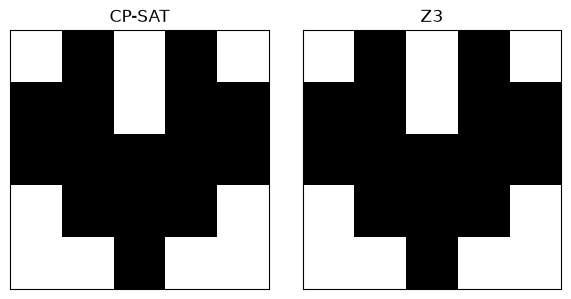

In [4]:
row_clues = [[1, 1], [2, 2], [5], [3], [1]]
col_clues = [[2], [4], [3], [4], [2]]

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, (name, solver_cls) in zip(
    axes, [("CP-SAT", CPSATSolver), ("Z3", Z3Solver)]
):
    grid = Picross(solver_cls(), row_clues, col_clues).solve()
    ax.imshow(grid, cmap="Greys")
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## Sudoku — benchmark des encodages
Comparaison de 3 encodages (booléen, entier, mixte) sur CP-SAT et Z3.

In [5]:
sudoku_grid = [
    [5, 3, 0, 0, 7, 0, 0, 0, 0],
    [6, 0, 0, 1, 9, 5, 0, 0, 0],
    [0, 9, 8, 0, 0, 0, 0, 6, 0],
    [8, 0, 0, 0, 6, 0, 0, 0, 3],
    [4, 0, 0, 8, 0, 3, 0, 0, 1],
    [7, 0, 0, 0, 2, 0, 0, 0, 6],
    [0, 6, 0, 0, 0, 0, 2, 8, 0],
    [0, 0, 0, 4, 1, 9, 0, 0, 5],
    [0, 0, 0, 0, 8, 0, 0, 7, 9],
]

encodings = [
    ("bool", SudokuBoolean),
    ("int", SudokuInteger),
    ("mixte", SudokuMixed),
]
solvers = [("CP-SAT", CPSATSolver), ("Z3", Z3Solver)]

cases = [
    (
        f"{enc_name}/{solver_name}",
        solver_cls,
        lambda s, cls=enc_cls: cls(s, sudoku_grid),
    )
    for enc_name, enc_cls in encodings
    for solver_name, solver_cls in solvers
]
results = run_benchmarks(cases)

df_bench = pd.DataFrame([r.__dict__ for r in results])
df_bench[["encoding", "solver"]] = df_bench["label"].str.split("/", expand=True)
df_bench

,label,solved,time_seconds,num_variables,num_constraints,encoding,solver
0,bool/CP-SAT,True,0.009650,729,354,bool,CP-SAT
1,bool/Z3,True,0.133895,729,354,bool,Z3
2,int/CP-SAT,True,0.015159,81,1002,int,CP-SAT
3,int/Z3,True,0.096183,81,1083,int,Z3
4,mixte/CP-SAT,True,0.004205,81,57,mixte,CP-SAT
5,mixte/Z3,True,0.048066,81,138,mixte,Z3


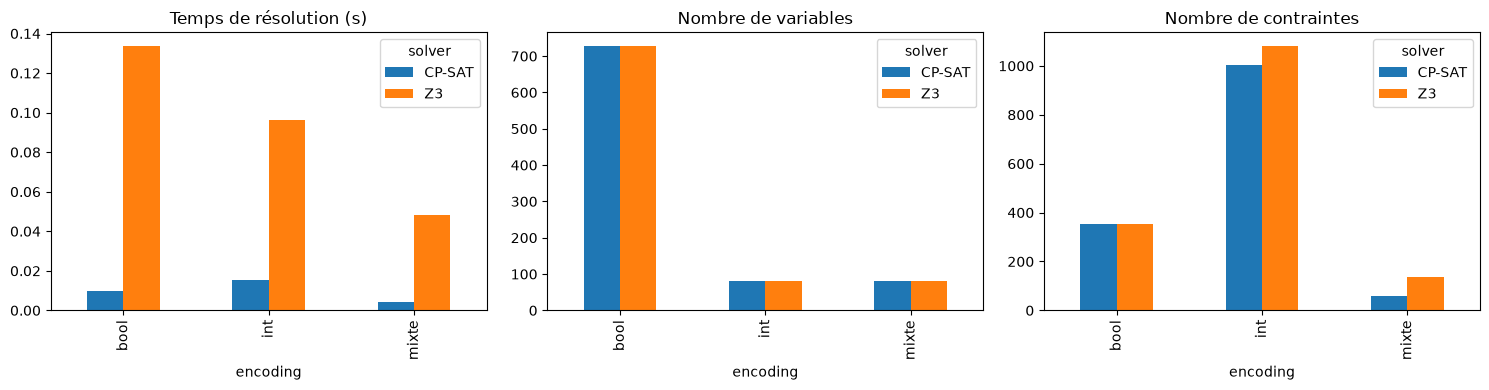

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_bench.pivot(
    index="encoding", columns="solver", values="time_seconds"
).plot.bar(ax=axes[0], title="Temps de résolution (s)")
df_bench.pivot(
    index="encoding", columns="solver", values="num_variables"
).plot.bar(ax=axes[1], title="Nombre de variables")
df_bench.pivot(
    index="encoding", columns="solver", values="num_constraints"
).plot.bar(ax=axes[2], title="Nombre de contraintes")

plt.tight_layout()
plt.show()

## Extension — Fill-A-Pix



In [7]:
_ = None

fill_a_pix_grid = [
    [0, _, _, 0, _, _, 4, _, _, 3, _, _, _, 0, _],
    [_, _, _, _, _, _, 5, 6, 5, _, 3, _, _, _, _],
    [0, _, _, 4, 5, 5, 5, _, 3, _, _, 3, 2, _, _],
    [_, _, 4, _, 4, 5, _, _, 3, _, _, 4, 4, 1, 0],
    [3, _, 6, _, 4, 3, _, 4, _, 3, _, 4, _, _, _],
    [_, _, _, _, _, _, _, _, _, 4, 4, 3, 3, 3, 2],
    [4, 5, _, _, 4, _, 4, _, 7, 5, 4, _, _, _, 3],
    [_, 5, 5, 6, _, 5, _, 6, _, _, 5, _, 2, _, 3],
    [_, 5, _, 7, _, 7, 8, _, 9, _, 7, 5, _, 3, _],
    [3, 5, 7, _, _, _, 7, 7, _, 7, _, 5, 4, _, _],
    [_, _, _, 7, _, _, _, 7, _, _, 7, _, 4, _, _],
    [_, _, 4, 5, _, 7, _, 6, 5, 6, _, _, 2, 1, 0],
    [0, _, 3, _, _, _, 7, _, _, 6, _, _, 1, 0, _],
    [_, 0, _, _, _, 7, _, 7, _, _, 3, 1, 0, _, _],
    [_, _, 0, _, _, _, _, _, _, _, _, _, _, 0, _],
]

fill_a_pix_solver = Fill_A_Pix(CPSATSolver(), fill_a_pix_grid)

fill_a_pix_start = perf_counter()
fill_a_pix_solved_grid = fill_a_pix_solver.solve()
fill_a_pix_end = perf_counter()

fill_a_pix_solve_time = fill_a_pix_end - fill_a_pix_start

print(f"Solved {len(fill_a_pix_grid)} by {len(fill_a_pix_grid[0])} in {fill_a_pix_solve_time:.5f}")

for row in fill_a_pix_solved_grid:
    print("".join("█" if cell else " " for cell in row))

Solved 15 by 15 in 0.01542
      ████     
     █ █  █    
    █ █ █  █   
  ████ █   █   
 ██   █  █ ██  
██ █   ██ █  █ 
█ █ █  █ █    █
█  █ █ ███ █  █
 ██████████  █ 
 ████████████  
 █  █ █  █  █  
  ██████████   
   █ ██ █ █    
    █ ██ █     
    ██████     


#### Expected Output

![image.png](https://fill-a-pix.net/img/example-solution.png)